# Wildfire Monitoring and Control Framework Results Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

## Load Datasets

In [13]:
df_base_case = pd.read_csv('base_case.csv')

In [14]:
df_base_case.head()

,TEST #,BURNED AREA,CASUALTIES,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,1,14.10%,2,NaN,NaN,NaN,NaN,NaN
1,2,9.80%,2,NaN,NaN,NaN,NaN,NaN
2,3,36.30%,6,NaN,NaN,NaN,NaN,NaN
3,4,5.90%,0,NaN,NaN,NaN,NaN,NaN
4,5,35.50%,9,NaN,NaN,NaN,NaN,NaN


In [15]:
df_base_case.drop(df_base_case.columns[3:], axis=1, inplace=True)

In [19]:
df_base_case['BURNED AREA'] = df_base_case['BURNED AREA'].str.rstrip('%').astype('float')

In [20]:
df_base_case.describe()

,TEST #,BURNED AREA,CASUALTIES
count,30.000000,30.000000,30.000000
mean,15.500000,23.910333,5.233333
std,8.803408,11.490330,3.234334
min,1.000000,5.100000,0.000000
25%,8.250000,16.825000,2.250000
50%,15.500000,22.900000,5.000000
75%,22.750000,32.675000,7.000000
max,30.000000,54.800000,15.000000


In [4]:
df_agentic_case = pd.read_csv("agentic_case.csv")

In [5]:
df_agentic_case.head()

,TEST #,BURNED AREA,CASUALTIES,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,1,17.36%,6,NaN,NaN,NaN,NaN,NaN
1,2,10.80%,3,NaN,NaN,NaN,NaN,NaN
2,3,7.80%,0,NaN,NaN,NaN,NaN,NaN
3,4,0.00%,0,NaN,NaN,NaN,NaN,NaN
4,5,30.80%,8,NaN,NaN,NaN,NaN,NaN


In [17]:
df_agentic_case.drop(df_agentic_case.columns[3:], axis=1, inplace=True)

In [21]:
df_agentic_case['BURNED AREA'] = df_agentic_case['BURNED AREA'].str.rstrip('%').astype('float')

In [22]:
df_agentic_case.describe()

,TEST #,BURNED AREA,CASUALTIES
count,30.000000,30.000000,30.000000
mean,15.500000,14.758667,3.233333
std,8.803408,10.029719,2.541834
min,1.000000,0.000000,0.000000
25%,8.250000,7.575000,2.000000
50%,15.500000,13.450000,3.000000
75%,22.750000,21.875000,4.000000
max,30.000000,37.600000,10.000000


## Data Visualization

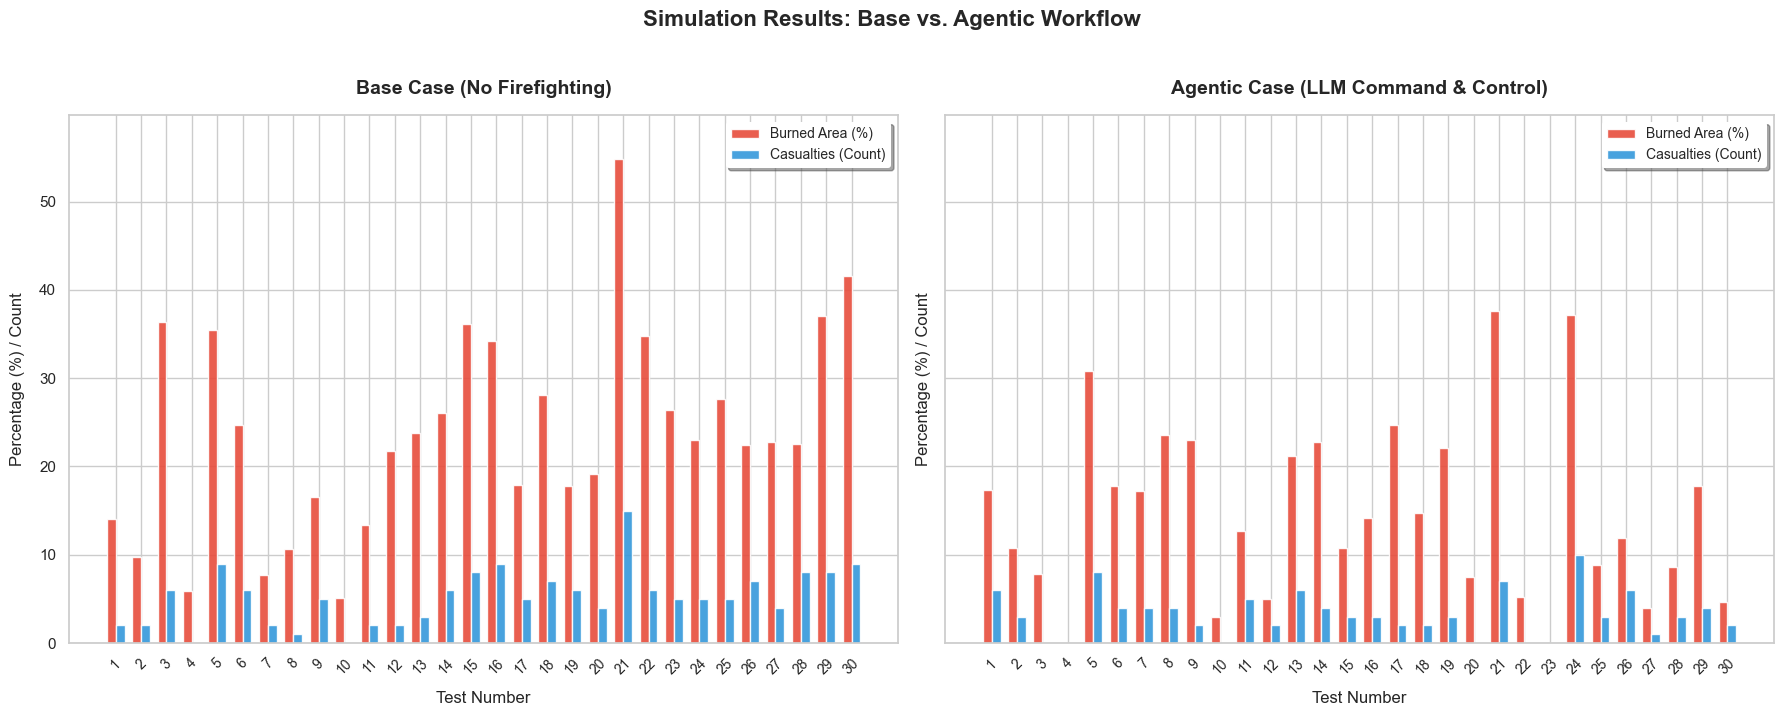

In [34]:
def plot_comparison(df_base, df_agentic):
    """
    Plots side-by-side bar graphs comparing BURNED AREA (%) and CASUALTIES
    for each test run in the base case and agentic case dataframes.
    """
    # Set style and aesthetic parameters
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
    
    # Harmonious color palette
    color_burned = "#e74c3c"  # Sleek red/salmon for burned area
    color_casualties = "#3498db"  # Sleek blue for casualties
    
    dataframes = [df_base, df_agentic]
    titles = ["Base Case (No Firefighting)", "Agentic Case (LLM Command & Control)"]
    
    for ax, df, title in zip(axes, dataframes, titles):
        # Ensure the test numbers are integers for clean labeling
        tests = df["TEST #"].astype(int)
        x = np.arange(len(tests))
        width = 0.35
        
        # Plotting grouped bars
        rects1 = ax.bar(x - width/2, df["BURNED AREA"], width, label="Burned Area (%)", color=color_burned, alpha=0.9)
        rects2 = ax.bar(x + width/2, df["CASUALTIES"], width, label="Casualties (Count)", color=color_casualties, alpha=0.9)
        
        # Aesthetics and labeling
        ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
        ax.set_xlabel("Test Number", fontsize=12, labelpad=10)
        ax.set_ylabel("Percentage (%) / Count", fontsize=12, labelpad=10)
        ax.set_xticks(x)
        ax.set_xticklabels(tests, rotation=45, fontsize=10)
        ax.legend(frameon=True, facecolor="white", edgecolor="none", shadow=True, fontsize=10)
        ax.set_ylim(0, max(df_base["BURNED AREA"].max(), df_agentic["BURNED AREA"].max()) + 5)
        
    plt.suptitle("Simulation Results: Base vs. Agentic Workflow", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# Call the plotting function to render the visualizations
plot_comparison(df_base_case, df_agentic_case)

## Statistical Testing

In [24]:
def perform_mannwhitney_test(df_base, df_compare, feature_name):
    """
    Runs the mann-whitney U test between the df_base and df_compare dataframes, focusing on comparing the feature denoted by feature_name

    Args:
        df_base: Asteroids near Earth that are not considered potentially hazardous.
        df_compare: Asteroids near Earth that are considered potentially hazardous.
        feature_name: The name of the feature to compare between the two groups.
    Returns:
        p: The associated p-value.
        base_median: The mean value of this feature for the neo dataframe.
        compare_median: The median value of this feature fo the pha dataframe.
    """

    df_base_copy = df_base.dropna(subset=[feature_name])
    df_compare_copy = df_compare.dropna(subset=[feature_name])

    x = df_base_copy[feature_name]
    y = df_compare_copy[feature_name]

    _, p =  mannwhitneyu(x, y)

    base_median = df_base_copy[feature_name].median()
    compare_median = df_compare_copy[feature_name].median()

    return p, base_median, compare_median

In [29]:
def print_results(feature_name, p_value, base_median, compare_median):
    """
    Prints out the results of the whitney tests
    Args:
        feature_name: Name of the feature tested.
        p_value: resulting p-value.
        base_median: Median value for the NEO dataframe.
        compare_median: Median value for the PHA dataframe.
    """
    print(f"Feature: {feature_name} p value: {p_value} Base Median: {base_median} Compare Median: {compare_median}")

In [25]:
p_burning, base_burn_median, compare_burn_median = perform_mannwhitney_test(
    df_base=df_base_case,
    df_compare=df_agentic_case,
    feature_name="BURNED AREA"
)

In [32]:
p_casualty, base_casaulty, compare_casualty = perform_mannwhitney_test(
    df_base=df_base_case,
    df_compare=df_agentic_case,
    feature_name="CASUALTIES"
)

In [31]:
print_results(
    p_value=p_burning,
    base_median=base_burn_median,
    compare_median=compare_burn_median,
    feature_name="Burned Area"
)

Feature: Burned Area p value: 0.0022632202447098668 Base Median: 22.9 Compare Median: 13.45


In [33]:
print_results(
    p_value=p_casualty,
    base_median=base_casaulty,
    compare_median=compare_casualty,
    feature_name="Burned Area"
)

Feature: Burned Area p value: 0.012377905977397893 Base Median: 5.0 Compare Median: 3.0
